# Bài tập: Tính và cập nhật trọng số bằng Gradient Descent

Mục tiêu:
- Tính dự đoán từ trọng số.
- Tính sai số và hàm mất mát.
- Tính gradient theo trọng số.
- Cập nhật trọng số theo công thức Gradient Descent.

Ràng buộc: chỉ dùng `numpy` cho phần code và `matplotlib` cho phần vẽ đồ thị.

## Công thức cần nhớ

### Linear Regression

Với mô hình tuyến tính một biến:

$$\hat{y} = wx + b$$

Hàm mất mát trung bình bình phương:

$$L = \frac{1}{n}\sum_{i=1}^{n}(\hat{y}_i - y_i)^2$$

Gradient:

$$\frac{\partial L}{\partial w} = \frac{2}{n}\sum_{i=1}^{n}x_i(\hat{y}_i - y_i)$$

$$\frac{\partial L}{\partial b} = \frac{2}{n}\sum_{i=1}^{n}(\hat{y}_i - y_i)$$

### Logistic Regression

Với mô hình logistic regression một biến, trước hết tính điểm tuyến tính:

$$z = wx + b$$

Đổi `z` thành xác suất bằng hàm sigmoid:

$$\hat{y} = \sigma(z) = \frac{1}{1 + e^{-z}}$$

Trong đó `\hat{y}` là xác suất mẫu thuộc lớp `1`.

Hàm mất mát Binary Cross Entropy cho một mẫu:

$$L = -\left[y\log(\hat{y}) + (1-y)\log(1-\hat{y})\right]$$

Hàm mất mát trung bình cho `n` mẫu:

$$L = -\frac{1}{n}\sum_{i=1}^{n}\left[y_i\log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i)\right]$$

Để tránh `log(0)`, chặn xác suất dự đoán trong khoảng rất nhỏ:

$$\hat{y} \leftarrow \mathrm{clip}(\hat{y}, \epsilon, 1 - \epsilon)$$

Ví dụ: `epsilon = 1e-12`.

Với sigmoid kết hợp Binary Cross Entropy, gradient có dạng gọn:

$$\frac{\partial L}{\partial w} = \frac{1}{n}\sum_{i=1}^{n}x_i(\hat{y}_i - y_i)$$

$$\frac{\partial L}{\partial b} = \frac{1}{n}\sum_{i=1}^{n}(\hat{y}_i - y_i)$$

### Cập nhật trọng số bằng Gradient Descent

Dùng cùng công thức cập nhật cho cả hai bài toán:

$$w \leftarrow w - \alpha\frac{\partial L}{\partial w}$$

$$b \leftarrow b - \alpha\frac{\partial L}{\partial b}$$


## Code mẫu: huấn luyện đầy đủ và quan sát loss giảm

Cell này minh họa toàn bộ quy trình Gradient Descent qua nhiều vòng lặp. Sau khi chạy, ta quan sát loss bằng biểu đồ matplotlib để thấy quá trình học diễn ra trực quan hơn.

epoch   0 | loss =  13.0789 | w =  0.405 | b =  0.700
epoch  20 | loss =   0.1158 | w =  1.901 | b =  2.585
epoch  40 | loss =   0.0645 | w =  2.182 | b =  2.441
epoch  60 | loss =   0.0359 | w =  2.389 | b =  2.329
epoch  79 | loss =   0.0206 | w =  2.538 | b =  2.249


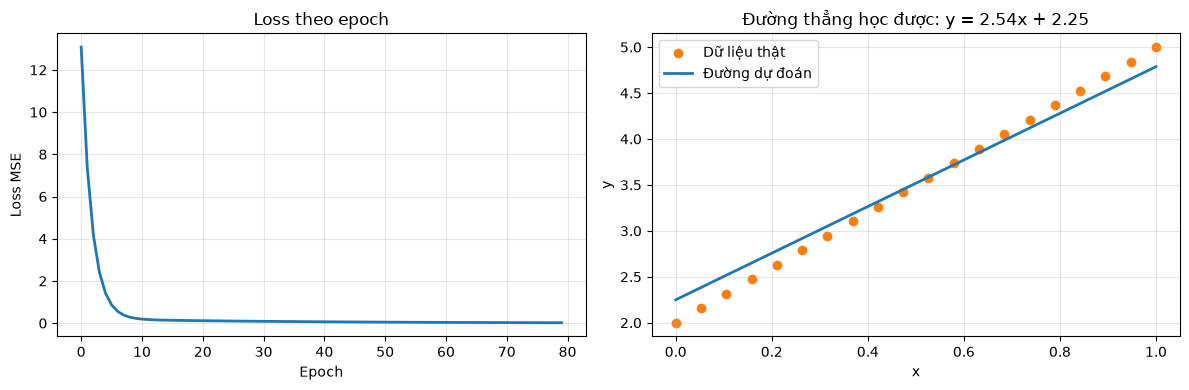


Kết quả cuối cùng:
w = 2.5375
b = 2.2493
Dự đoán khi x = 1.5: 6.0556


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Dữ liệu mẫu: y gần đúng bằng 3x + 2
# Dùng x trong khoảng 0 đến 1 để loss giảm mượt và dễ quan sát hơn.
x = np.linspace(0, 1, 20)
y = 3 * x + 2

# Khởi tạo trọng số
w = 0.0
b = 0.0
learning_rate = 0.1
epochs = 80
loss_history = []

def predict(x, w, b):
    return w * x + b

def mse_loss(y_true, y_pred):
    error = y_pred - y_true
    return np.mean(error ** 2)

def compute_gradients(x, y_true, y_pred):
    error = y_pred - y_true
    grad_w = 2 * np.mean(x * error)
    grad_b = 2 * np.mean(error)
    return grad_w, grad_b

for epoch in range(epochs):
    # Tính giá trị dự đoán
    y_pred = predict(x, w, b)

    # Tính loss
    loss = mse_loss(y, y_pred)
    loss_history.append(loss)

    # Tính gradient
    grad_w, grad_b = compute_gradients(x, y, y_pred)

    # Cập nhật trọng số
    w = w - learning_rate * grad_w
    b = b - learning_rate * grad_b

    if epoch % 20 == 0 or epoch == epochs - 1:
        print(f"epoch {epoch:3d} | loss = {loss:8.4f} | w = {w:6.3f} | b = {b:6.3f}")

def plot_training_result(loss_history, x, y_true, w, b):
    epochs_axis = np.arange(len(loss_history))
    y_pred = predict(x, w, b)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs_axis, loss_history, color="tab:blue", linewidth=2)
    axes[0].set_title("Loss theo epoch")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss MSE")
    axes[0].grid(True, alpha=0.3)

    axes[1].scatter(x, y_true, color="tab:orange", label="Dữ liệu thật")
    axes[1].plot(x, y_pred, color="tab:blue", linewidth=2, label="Đường dự đoán")
    axes[1].set_title(f"Đường thẳng học được: y = {w:.2f}x + {b:.2f}")
    axes[1].set_xlabel("x")
    axes[1].set_ylabel("y")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_training_result(loss_history, x, y, w, b)

print("\nKết quả cuối cùng:")
print(f"w = {w:.4f}")
print(f"b = {b:.4f}")
print(f"Dự đoán khi x = 1.5: {predict(1.5, w, b):.4f}")

## Bài 1: Linear Regression với dữ liệu rải quanh một đường thẳng

Bộ dữ liệu bên dưới mô phỏng các điểm `x` nằm rải rác quanh đường thẳng thật gần đúng `y = 2.4x - 1.2`.

Yêu cầu học sinh:
- Tính dự đoán `y_pred`.
- Tính MSE loss.
- Tính gradient theo `w` và `b`.
- Cập nhật `w`, `b` bằng Gradient Descent.
- In loss để quan sát quá trình học.

In [ ]:
import numpy as np

# Dữ liệu linear regression
x_linear = np.array([-3.0, -2.4, -1.8, -1.2, -0.6, 0.0, 0.6, 1.2, 1.8, 2.4, 3.0])
y_linear = np.array([-8.7, -6.6, -5.4, -4.0, -2.4, -1.0, 0.0, 1.6, 3.0, 4.7, 6.2])

# Tham số khởi tạo đã cho
w_linear = 0.3
b_linear = 0.0
learning_rate_linear = 0.03
epochs_linear = 120

print("x_linear =", x_linear)
print("y_linear =", y_linear)
print("w_linear ban đầu =", w_linear)
print("b_linear ban đầu =", b_linear)
print("learning_rate_linear =", learning_rate_linear)

### Bài 1.1: Hoàn thiện hàm cho Linear Regression


In [ ]:
# TODO: viết hàm predict_linear(x, w, b)

# TODO: viết hàm mse_loss(y_true, y_pred)

# TODO: viết hàm compute_linear_gradients(x, y_true, y_pred)

### Bài 1.2: Huấn luyện mô hình Linear Regression

Sau khi chạy xong, `w_linear` và `b_linear` nên tiến gần tới đường thẳng phù hợp với dữ liệu.

In [ ]:
loss_history_linear = []

# TODO: chạy vòng lặp Gradient Descent trong epochs_linear
# TODO: tính y_pred_linear bằng predict_linear
# TODO: tính loss_linear bằng mse_loss và lưu vào loss_history_linear
# TODO: tính grad_w_linear, grad_b_linear bằng compute_linear_gradients
# TODO: cập nhật w_linear = w_linear - learning_rate_linear * grad_w_linear
# TODO: cập nhật b_linear = b_linear - learning_rate_linear * grad_b_linear
# TODO: in epoch, loss_linear, w_linear, b_linear sau mỗi 20 epochs

# TODO: in kết quả cuối cùng của w_linear và b_linear

### Bài 1.3: Viết hàm plot kết quả Linear Regression

Viết hàm trực quan hóa để kiểm tra đường thẳng mô hình học được có khớp với dữ liệu hay không.

In [ ]:
# TODO: import matplotlib.pyplot as plt

# TODO: viết hàm plot_linear_result(x, y_true, w, b, loss_history)
# Gợi ý: tạo biểu đồ gồm 2 phần
# - Phần 1: vẽ loss_history theo epoch
# - Phần 2: scatter dữ liệu thật và vẽ đường y_pred = w * x + b
# - Thêm title, xlabel, ylabel, legend để biểu đồ dễ đọc

# TODO: gọi plot_linear_result(x_linear, y_linear, w_linear, b_linear, loss_history_linear)

## Bài 2: Logistic Regression

Bộ dữ liệu bên dưới mô phỏng một biến đầu vào `x`. Nhãn `y = 0` thường nằm ở vùng `x` nhỏ hơn, nhãn `y = 1` thường nằm ở vùng `x` lớn hơn.

Yêu cầu học sinh:
- Tính dự đoán `z` từ trọng số.
- Đổi `z` thành xác suất bằng sigmoid.
- Tính Binary Cross Entropy loss.
- Tính gradient theo `w` và `b`.
- Cập nhật `w`, `b` bằng Gradient Descent.

In [ ]:
# Dữ liệu logistic regression
x_logistic = np.array([-3.2, -2.7, -2.1, -1.5, -0.9, -0.4, 0.1, 0.5, 0.9, 1.4, 2.0, 2.6, 3.1])
y_logistic = np.array([0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1])

# Tham số khởi tạo
w_logistic = -0.2
b_logistic = 0.1
learning_rate_logistic = 0.15
epochs_logistic = 150

print("x_logistic =", x_logistic)
print("y_logistic =", y_logistic)
print("w_logistic ban đầu =", w_logistic)
print("b_logistic ban đầu =", b_logistic)
print("learning_rate_logistic =", learning_rate_logistic)

### Bài 2.1: Hoàn thiện hàm cho Logistic Regression

Dùng `epsilon` nhỏ khi tính log để tránh `log(0)`.

In [ ]:
# TODO: viết hàm sigmoid(z)
# TODO: viết hàm predict_proba_logistic(x, w, b)

# TODO: viết hàm binary_cross_entropy(y_true, y_pred_proba)
# Gợi ý:
# epsilon = 1e-12
# y_pred_proba = clip(y_pred_proba, epsilon, 1 - epsilon)
# loss = -mean(y_true * log(y_pred_proba) + (1 - y_true) * log(1 - y_pred_proba))

# TODO: viết hàm compute_logistic_gradients(x, y_true, y_pred_proba)

### Bài 2.2: Huấn luyện mô hình Logistic Regression

Sau khi huấn luyện, xác suất dự đoán nên thấp hơn cho phần lớn điểm lớp `0` và cao hơn cho phần lớn điểm lớp `1`.

In [ ]:
loss_history_logistic = []

# TODO: chạy vòng lặp Gradient Descent trong epochs_logistic
# TODO: tính y_pred_proba_logistic bằng predict_proba_logistic
# TODO: tính loss_logistic bằng binary_cross_entropy và lưu vào loss_history_logistic
# TODO: tính grad_w_logistic, grad_b_logistic bằng compute_logistic_gradients
# TODO: cập nhật w_logistic = w_logistic - learning_rate_logistic * grad_w_logistic
# TODO: cập nhật b_logistic = b_logistic - learning_rate_logistic * grad_b_logistic
# TODO: in epoch, loss_logistic, w_logistic, b_logistic sau mỗi 25 epochs

# TODO: tính xác suất cuối cùng cho từng điểm x_logistic
# TODO: đổi xác suất thành nhãn dự đoán với ngưỡng 0.5
# TODO: in xác suất, nhãn dự đoán, và so sánh với y_logistic

### Bài 2.3: Viết hàm plot kết quả Logistic Regression

Viết hàm trực quan hóa để kiểm tra loss giảm và xác suất dự đoán theo từng điểm dữ liệu.

In [ ]:
# TODO: import matplotlib.pyplot as plt

# TODO: viết hàm plot_logistic_result(x, y_true, y_pred_proba, loss_history)
# Gợi ý: tạo biểu đồ gồm 2 phần
# - Phần 1: vẽ loss_history theo epoch
# - Phần 2: scatter dữ liệu thật và scatter xác suất dự đoán
# - Có thể vẽ thêm đường ngang y = 0.5 để thể hiện ngưỡng phân lớp
# - Thêm title, xlabel, ylabel, legend để biểu đồ dễ đọc

# TODO: tính final_proba_logistic bằng predict_proba_logistic(x_logistic, w_logistic, b_logistic)
# TODO: gọi plot_logistic_result(x_logistic, y_logistic, final_proba_logistic, loss_history_logistic)